In [2]:
import pandas as pd
import numpy as np

In [31]:
import requests

archivos = {
    "BX-Books.csv": "https://raw.githubusercontent.com/ashwanidv100/Recommendation-System---Book-Crossing-Dataset/master/BX-CSV-Dump/BX-Books.csv",
    "BX-Users.csv": "https://raw.githubusercontent.com/ashwanidv100/Recommendation-System---Book-Crossing-Dataset/master/BX-CSV-Dump/BX-Users.csv",
    "BX-Book-Ratings.csv": "https://raw.githubusercontent.com/ashwanidv100/Recommendation-System---Book-Crossing-Dataset/master/BX-CSV-Dump/BX-Book-Ratings.csv"
}

for nombre, url in archivos.items():
    print(f"Descargando {nombre}...")
    
    respuesta = requests.get(url)
    respuesta.raise_for_status()
    
    with open(nombre, "wb") as archivo:
        archivo.write(respuesta.content)
    
    print(f"{nombre} descargado correctamente.")


Descargando BX-Books.csv...
BX-Books.csv descargado correctamente.
Descargando BX-Users.csv...
BX-Users.csv descargado correctamente.
Descargando BX-Book-Ratings.csv...
BX-Book-Ratings.csv descargado correctamente.


In [3]:
ratings = pd.read_csv('BX-Book-Ratings.csv', delimiter=";", encoding="latin1")
users = pd.read_csv('BX-Users.csv', delimiter=";", encoding="latin1")
books = pd.read_csv('BX-Books.csv', delimiter=";", encoding="latin1", on_bad_lines='skip')

C:\Users\esper\AppData\Local\Temp\ipykernel_5988\637790257.py:3: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('BX-Books.csv', delimiter=";", encoding="latin1", on_bad_lines='skip')


## Análisis y corrección de la tabla users

In [33]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [34]:
users.describe()

,User-ID,Age
count,278858.00000,168096.000000
mean,139429.50000,34.751434
std,80499.51502,14.428097
min,1.00000,0.000000
25%,69715.25000,24.000000
50%,139429.50000,32.000000
75%,209143.75000,44.000000
max,278858.00000,244.000000


In [35]:
users.isna().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

Problemas:
* Rangos inválidos
* Presencia de Nan

Tratamiento:
* Convertir las edades fuera de rango en Nan
* Mantener los valores Nan
* Transformar las edades a entero

In [5]:
# Convertir edades fuera de rango a Nan
users['Age_Clean'] = users['Age'].apply(lambda x:x if (pd.notna(x) and 10 <= x <=90) else np.nan).astype('Int64')

Text(0.5, 1.0, 'Histograma de la variable Age_Clean')

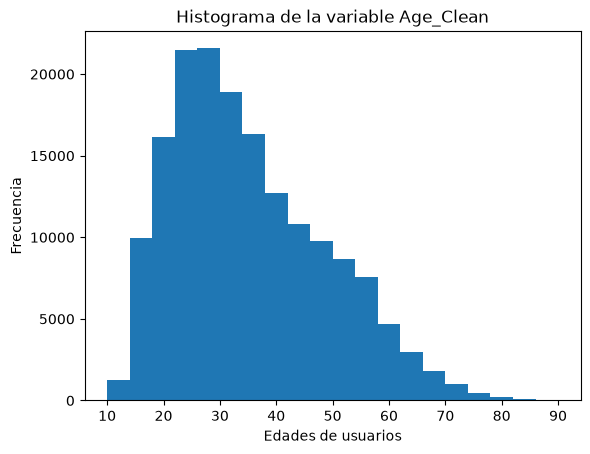

In [6]:
import matplotlib.pyplot as plt

plt.hist(users['Age_Clean'], bins=20)
plt.xlabel("Edades de usuarios")
plt.ylabel("Frecuencia")
plt.title("Histograma de la variable Age_Clean")

## Análisis y corrección de la tabla ratings

In [38]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   User-ID      1149780 non-null  int64
 1   ISBN         1149780 non-null  str  
 2   Book-Rating  1149780 non-null  int64
dtypes: int64(2), str(1)
memory usage: 26.3 MB


In [20]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [11]:
ratings.describe()

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


In [12]:
ratings.isna().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Problema:

La presencia de 0 indica que el lector leyó el libro pero que no dio su clasificación.

Esto puede provocar que el usuario se clasifique como un usuario exigente o con un historial largo cuando en realidad no califico la cantidad suficiente o sus clasificaciones fueron positivas.

Tratamiento:
* Filtrar ratings que tengan clasificaciones mayor a 0.

In [7]:
ratings_filtrados = ratings[ratings['Book-Rating'] > 0].copy()

Text(0.5, 1.0, 'Histograma de la variable Book-Rating')

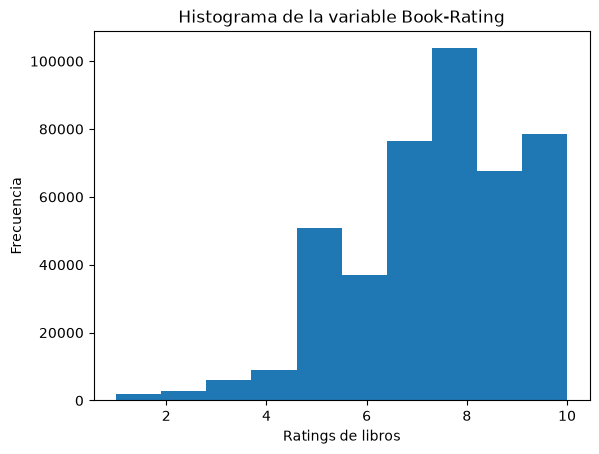

In [40]:
import matplotlib.pyplot as plt

plt.hist(ratings_filtrados['Book-Rating'], bins=10)
plt.xlabel("Ratings de libros")
plt.ylabel("Frecuencia")
plt.title("Histograma de la variable Book-Rating")

## Análisis y corrección de la tabla book

In [41]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  str   
 1   Book-Title           271360 non-null  str   
 2   Book-Author          271358 non-null  str   
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  str   
 5   Image-URL-S          271360 non-null  str   
 6   Image-URL-M          271360 non-null  str   
 7   Image-URL-L          271357 non-null  str   
dtypes: object(1), str(7)
memory usage: 16.6+ MB


In [8]:
books = books.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis=1)

In [43]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


# Crear los grupos de usuarios

### Merge de las tablas

In [9]:
df = pd.merge(ratings_filtrados, books, on='ISBN')
df = pd.merge(df, users, on='User-ID')


In [10]:
resumen_usuario = (df.groupby("User-ID")
                    .agg(
                        n_ratings=("Book-Rating", "size"),
                        avg_rating=("Book-Rating", "mean")
                    ).reset_index()
                   )

resumen_usuario = resumen_usuario.merge(
    users[["User-ID", "Age_Clean"]], 
    on="User-ID", 
    how="left"
)

# Identificar grupo de hitorial
hist_median = resumen_usuario["n_ratings"].median()

# 0 usuarios con historial corto, 1 usuarios con historial largo
resumen_usuario["Grupo_Historial"] = resumen_usuario["n_ratings"].apply(lambda x: int(x > hist_median))

# Identificar grupo de exigencia: 0 Exigente, 1 normal, 2 generoso
mean_avg = resumen_usuario["avg_rating"].mean()
std_avg = resumen_usuario["avg_rating"].std()

def asignar_grupo_exigencia(avg):
    if pd.isna(avg):
        return np.nan
    if avg < mean_avg - std_avg:
        return 0
    elif avg > mean_avg + std_avg:
        return 2
    else:
        return 1

resumen_usuario["Grupo_Exigencia"] = resumen_usuario["avg_rating"].apply(asignar_grupo_exigencia)

# Identificar grupo etario
def asignar_grupo_etario(age):
    if pd.isna(age):
        return np.nan
    if age <= 24:
        return 'Jóvenes'
    elif age <= 64:
        return 'Adultos'
    else:
        return 'Mayores'

resumen_usuario['Grupo_Etario'] = resumen_usuario['Age_Clean'].apply(asignar_grupo_etario)

print(hist_median)
print(mean_avg)
print(std_avg)
print(resumen_usuario.head(10))
print(resumen_usuario["Grupo_Exigencia"].value_counts())
print(resumen_usuario["Grupo_Historial"].value_counts())
print(resumen_usuario["Grupo_Etario"].value_counts())



1.0
7.48717697959123
1.6182661094541058
   User-ID  n_ratings  avg_rating  Age_Clean  Grupo_Historial  \
0        8          7    5.571429       <NA>                1   
1        9          1    6.000000       <NA>                0   
2       12          1   10.000000       <NA>                0   
3       14          3    5.333333       <NA>                1   
4       16          1    9.000000       <NA>                0   
5       17          4    5.250000       <NA>                1   
6       19          1    7.000000         14                0   
7       22          1    7.000000       <NA>                0   
8       26          2    9.500000       <NA>                1   
9       32          1    8.000000       <NA>                0   

   Grupo_Exigencia Grupo_Etario  
0                0          NaN  
1                1          NaN  
2                2          NaN  
3                0          NaN  
4                1          NaN  
5                0          NaN  
6     

### Merge de los resultados

In [11]:
df = df.merge(
    resumen_usuario[["User-ID", "n_ratings", "avg_rating", "Grupo_Historial", "Grupo_Exigencia", "Grupo_Etario"]],
    on="User-ID",
    how="left"
)

# Guardado de la tabla creada

In [16]:
df.to_csv('./resumen_usuario.csv', index=False)